# Notebook 03 - Multivariate Analysis

This notebook analyses the structure of the cleaned dataset to decide which variables are most informative and which should be left out of the composite index.

**Steps:**
1. Correlation matrix - identify highly correlated variables (r > 0.85)
2. PCA (Principal Component Analysis) - reduce dimensionality and understand variance structure
3. Scree plot - determine how many components explain the data
4. PCA biplot - visualise countries and variable loadings on PC1 and PC2
5. Variable selection - decide which variables to keep for the CRI

Results are saved for use in the next notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

PROCESSED = '../data/processed/'

df = pd.read_csv(f'{PROCESSED}cleaned_data.csv')
print(f'Loaded shape: {df.shape}')
display(df.head())

Loaded shape: (35, 12)


,country,gci_overall,ncsi_score,ddl_score,gci_capacity,gci_cooperation,gci_legal,gci_organisational,gci_technical,internet_penetration,gdp_per_capita,hdi_score
0,Argentina,50.12,63.64,60.43,3.135239,9.983615,14.553914,10.186348,12.962927,89.228972,14261.846567,0.849
1,Australia,97.47,66.23,77.61,19.720586,19.127009,20.000000,19.490706,18.516867,96.116096,65058.377315,0.946
2,Austria,93.89,68.83,75.76,18.735104,17.143173,18.924699,17.599348,19.115610,95.334671,56579.504175,0.926
3,Belgium,96.25,94.81,74.07,19.596973,20.000000,20.000000,17.884250,19.055728,94.626251,55291.475454,0.942
4,Brazil,96.60,51.95,59.11,19.367390,19.703050,20.000000,18.137006,19.363917,84.150602,10377.589772,0.760


## 1. Select Indicator Variables

We separate the country identifier and benchmark columns (gci_score, hdi_score, gdp_per_capita) from the indicator variables that will be used to build the composite index.

In [2]:
# Columns used as external benchmarks, not part of the CRI construction
EXCLUDED_FROM_CRI = ['country', 'gci_overall', 'hdi_score', 'gdp_per_capita']

indicator_cols = [c for c in df.columns if c not in EXCLUDED_FROM_CRI]
print(f'Indicator variables ({len(indicator_cols)}): {indicator_cols}')

X = df[indicator_cols].copy()
countries = df['country'].values

Indicator variables (8): ['ncsi_score', 'ddl_score', 'gci_capacity', 'gci_cooperation', 'gci_legal', 'gci_organisational', 'gci_technical', 'internet_penetration']


## 2. Correlation Matrix

A high correlation between two variables (|r| > 0.85) means they carry similar information. Keeping both would over-weight that dimension in the composite index. We flag these pairs for potential removal.

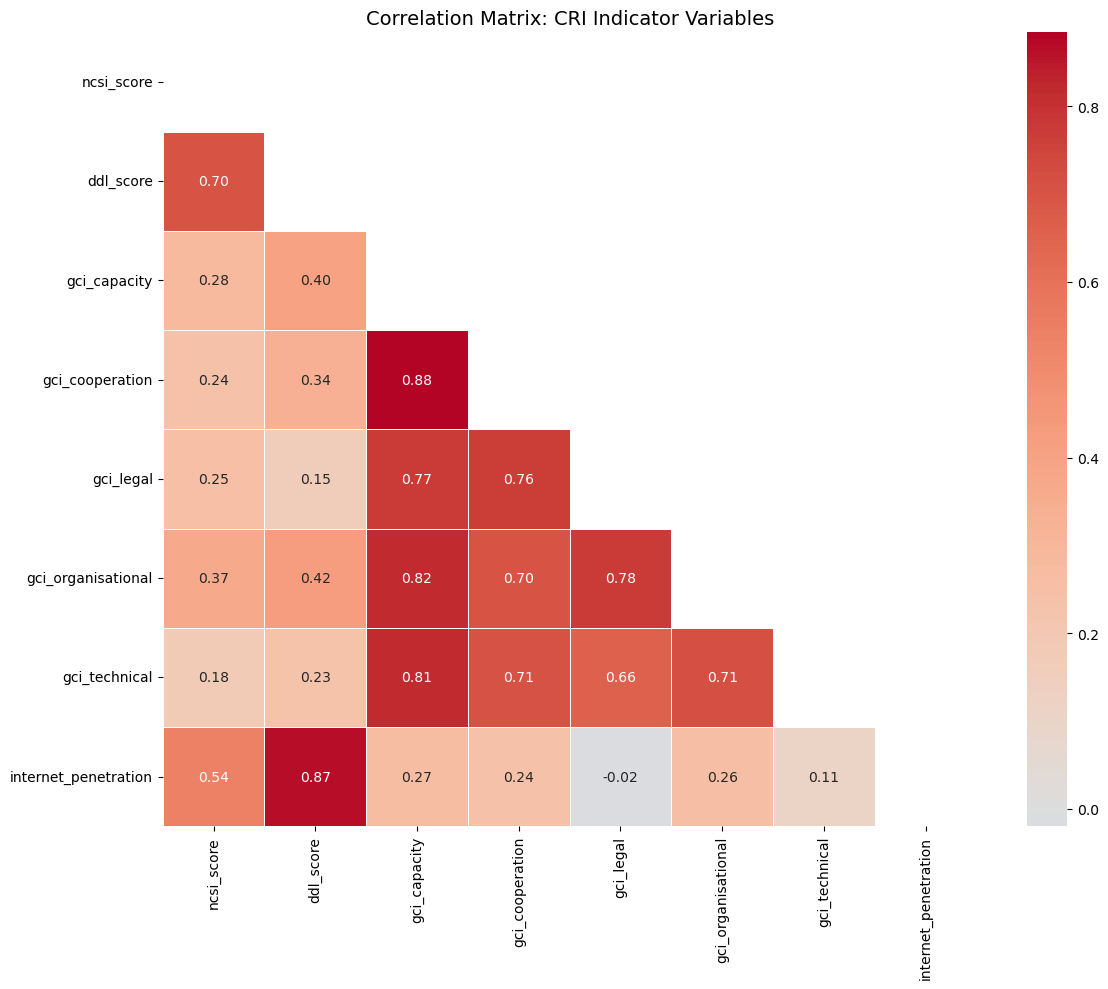

Saved: report/figures/03_correlation_matrix.png


In [3]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix: CRI Indicator Variables', fontsize=14)
plt.tight_layout()
plt.savefig('../report/figures/03_correlation_matrix.png', dpi=150)
plt.show()
print('Saved: report/figures/03_correlation_matrix.png')

In [4]:
# Report pairs with |r| > 0.85
THRESHOLD = 0.85
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > THRESHOLD:
            high_corr_pairs.append({
                'variable_1': corr.columns[i],
                'variable_2': corr.columns[j],
                'correlation': round(r, 4)
            })

if high_corr_pairs:
    print(f'Highly correlated pairs (|r| > {THRESHOLD}):')
    display(pd.DataFrame(high_corr_pairs))
else:
    print(f'No pairs with |r| > {THRESHOLD} found.')

Highly correlated pairs (|r| > 0.85):


,variable_1,variable_2,correlation
0,ddl_score,internet_penetration,0.8694
1,gci_capacity,gci_cooperation,0.8841


## 3. Standardise Variables for PCA

PCA is sensitive to variable scale. We use `StandardScaler` (zero mean, unit variance) before fitting PCA so that variables with larger numerical ranges do not dominate the components.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Scaled shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Std (should be ~1): {X_scaled.std(axis=0).round(4)}')

Scaled shape: (35, 8)
Mean (should be ~0): [-0.  0.  0. -0.  0.  0. -0. -0.]
Std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## 4. PCA - Fit and Scree Plot

The scree plot shows the proportion of total variance explained by each principal component. We look for the elbow point where additional components explain diminishing variance.

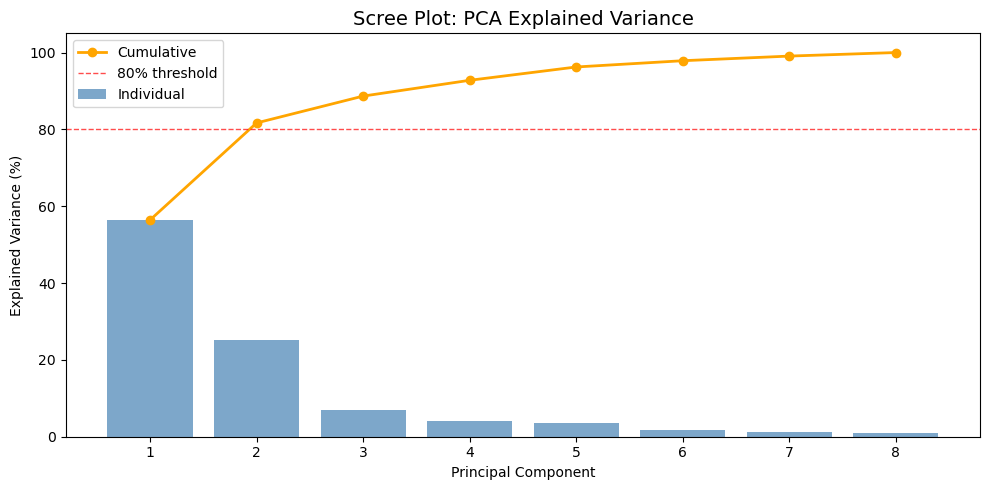

Saved: report/figures/03_scree_plot.png

Variance explained per component:
  PC1: 56.4%  (cumulative: 56.4%)
  PC2: 25.3%  (cumulative: 81.7%)
  PC3: 7.0%  (cumulative: 88.7%)
  PC4: 4.1%  (cumulative: 92.8%)
  PC5: 3.5%  (cumulative: 96.2%)
  PC6: 1.6%  (cumulative: 97.9%)
  PC7: 1.2%  (cumulative: 99.1%)
  PC8: 0.9%  (cumulative: 100.0%)


In [6]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 5))
components = range(1, len(explained) + 1)
ax.bar(components, explained * 100, alpha=0.7, color='steelblue', label='Individual')
ax.plot(components, cumulative * 100, marker='o', color='orange', linewidth=2, label='Cumulative')
ax.axhline(y=80, color='red', linestyle='--', linewidth=1, alpha=0.7, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot: PCA Explained Variance', fontsize=14)
ax.legend()
ax.set_xticks(list(components))
plt.tight_layout()
plt.savefig('../report/figures/03_scree_plot.png', dpi=150)
plt.show()
print('Saved: report/figures/03_scree_plot.png')

print('\nVariance explained per component:')
for i, (ind, cum) in enumerate(zip(explained, cumulative), 1):
    print(f'  PC{i}: {ind*100:.1f}%  (cumulative: {cum*100:.1f}%)')

## 5. PCA Loadings

Loadings show how strongly each original variable contributes to each principal component. Large absolute loadings (>0.3) on PC1 indicate the most important variables.

In [7]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=indicator_cols,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print('PCA Loadings (first 4 components):')
display(loadings[['PC1', 'PC2', 'PC3', 'PC4']].round(3))

# Variables with low loading on PC1 (|loading| < 0.1) may have limited contribution
low_loading = loadings['PC1'][abs(loadings['PC1']) < 0.1].index.tolist()
print(f'\nVariables with low PC1 loading (<0.1): {low_loading}')

PCA Loadings (first 4 components):


,PC1,PC2,PC3,PC4
ncsi_score,0.242,0.440,0.726,0.172
ddl_score,0.281,0.534,-0.128,-0.008
gci_capacity,0.438,-0.151,-0.195,-0.034
gci_cooperation,0.410,-0.168,-0.202,-0.461
gci_legal,0.377,-0.289,0.367,-0.372
gci_organisational,0.418,-0.097,0.132,0.095
gci_technical,0.377,-0.237,-0.200,0.771
internet_penetration,0.208,0.567,-0.429,-0.123



Variables with low PC1 loading (<0.1): []


## 6. PCA Biplot - PC1 vs PC2

The biplot projects countries onto PC1 and PC2 and overlays variable loading arrows. Countries that are close together have similar cybersecurity profiles. Variables pointing in the same direction are correlated with each other.

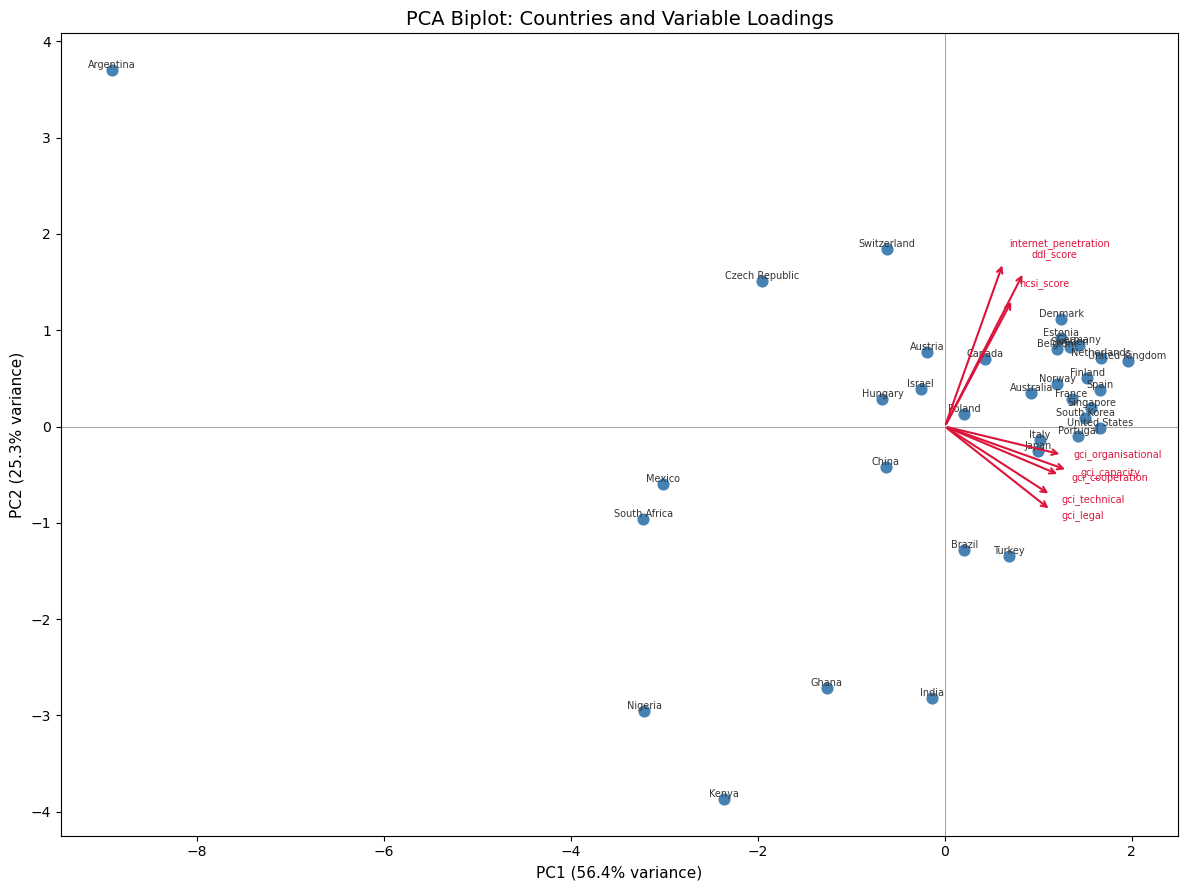

Saved: report/figures/03_pca_biplot.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 9))

# Plot countries
ax.scatter(X_pca[:, 0], X_pca[:, 1], color='steelblue', s=60, zorder=3)
for i, country in enumerate(countries):
    ax.annotate(country, (X_pca[i, 0], X_pca[i, 1]),
                fontsize=7, ha='center', va='bottom', color='#333333')

# Plot loading arrows (scaled for visibility)
scale = 3
for var in indicator_cols:
    ax.annotate('',
        xy=(loadings.loc[var, 'PC1'] * scale, loadings.loc[var, 'PC2'] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5)
    )
    ax.text(
        loadings.loc[var, 'PC1'] * scale * 1.1,
        loadings.loc[var, 'PC2'] * scale * 1.1,
        var, fontsize=7, color='crimson'
    )

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA Biplot: Countries and Variable Loadings', fontsize=14)
plt.tight_layout()
plt.savefig('../report/figures/03_pca_biplot.png', dpi=150)
plt.show()
print('Saved: report/figures/03_pca_biplot.png')

## 7. Variable Selection Decision

Based on the correlation analysis and PCA loadings, we document which variables are kept in the CRI and which are excluded, with justification.

In [9]:
# Two high-correlation pairs were identified (|r| > 0.85):
#   ddl_score vs internet_penetration: r=0.869
#   gci_capacity vs gci_cooperation:   r=0.884
#
# Decision: remove ddl_score.
# ddl_score (Digital Development Level) heavily overlaps with
# internet_penetration, which is a more direct and widely used
# infrastructure measure from the World Bank. Keeping internet_penetration
# avoids double-counting the technical connectivity dimension.
#
# gci_capacity and gci_cooperation are kept despite r=0.884 because
# they measure distinct concepts (education/training vs international
# partnerships) and removing either would leave a sub-index dimension
# without coverage.

REMOVED_VARS = ['ddl_score']

KEPT_VARS = [v for v in indicator_cols if v not in REMOVED_VARS]
print(f'Variables kept for CRI ({len(KEPT_VARS)}): {KEPT_VARS}')
print(f'Variables removed ({len(REMOVED_VARS)}): {REMOVED_VARS}')

pd.Series(KEPT_VARS, name='kept_variables').to_csv(f'{PROCESSED}kept_variables.csv', index=False)
print(f'Saved kept variable list to {PROCESSED}kept_variables.csv')


Variables kept for CRI (7): ['ncsi_score', 'gci_capacity', 'gci_cooperation', 'gci_legal', 'gci_organisational', 'gci_technical', 'internet_penetration']
Variables removed (1): ['ddl_score']
Saved kept variable list to ../data/processed/kept_variables.csv


## 8. Save PCA Scores

In [10]:
pca_df = pd.DataFrame(X_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
pca_df.insert(0, 'country', countries)
pca_df.to_csv(f'{PROCESSED}pca_scores.csv', index=False)
print(f'Saved PCA scores to {PROCESSED}pca_scores.csv')
display(pca_df.head())

Saved PCA scores to ../data/processed/pca_scores.csv


,country,PC1,PC2,PC3,PC4
0,Argentina,-8.911299,3.703240,0.201002,-0.143956
1,Australia,0.925869,0.347775,-0.380958,-0.488016
2,Austria,-0.188060,0.777952,-0.546889,0.591741
3,Belgium,1.198540,0.802760,0.629503,-0.145122
4,Brazil,0.208232,-1.282992,-0.712783,-0.217745
